# Import Libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
import sqlite3

# Connect DB
1. make connection using sqlite3
2. make a cursor to execute queries and interact with db

In [2]:
con = sqlite3.connect('Chinook_Sqlite.sqlite')

In [3]:
cur = con.cursor()

# Explore DB

## Explore DB Tables

In [4]:
res = cur.execute("SELECT name FROM sqlite_master where type='table'")
tables = [table[0] for table in res.fetchall()]

In [5]:
print(f"number of tables in db = {len(tables)}")

number of tables in db = 11


In [6]:
for table in tables: 
    print(table, end=", ")

Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track, 

In [7]:
table_size = []
for t in tables: 
    cur.execute(f"Select Count(*) from {t} ;")
    table_size.append((t, cur.fetchone()[0]))

In [8]:
for ts in table_size: 
    print(f"Table `{ts[0]}` size: {ts[1]} record")

Table `Album` size: 347 record
Table `Artist` size: 275 record
Table `Customer` size: 59 record
Table `Employee` size: 8 record
Table `Genre` size: 25 record
Table `Invoice` size: 412 record
Table `InvoiceLine` size: 2240 record
Table `MediaType` size: 5 record
Table `Playlist` size: 18 record
Table `PlaylistTrack` size: 8715 record
Table `Track` size: 3503 record


## check tables schema 

In [9]:
def get_table_schema(cursor, table_name):
    cursor.execute(f'PRAGMA table_info({table_name});')
    columns = cursor.fetchall()
    return columns

In [10]:
for table in tables:
    print(f"\n---------- Table: {table} ---------")
    columns = get_table_schema(cur, table)
    for col in columns: 
        print(f" {col[1]}  ({col[2]})  {'NOT NULL' if col[3] else ''} {'Primary Key' if col[5] else ''} ")  


---------- Table: Album ---------
 AlbumId  (INTEGER)  NOT NULL Primary Key 
 Title  (NVARCHAR(160))  NOT NULL  
 ArtistId  (INTEGER)  NOT NULL  

---------- Table: Artist ---------
 ArtistId  (INTEGER)  NOT NULL Primary Key 
 Name  (NVARCHAR(120))    

---------- Table: Customer ---------
 CustomerId  (INTEGER)  NOT NULL Primary Key 
 FirstName  (NVARCHAR(40))  NOT NULL  
 LastName  (NVARCHAR(20))  NOT NULL  
 Company  (NVARCHAR(80))    
 Address  (NVARCHAR(70))    
 City  (NVARCHAR(40))    
 State  (NVARCHAR(40))    
 Country  (NVARCHAR(40))    
 PostalCode  (NVARCHAR(10))    
 Phone  (NVARCHAR(24))    
 Fax  (NVARCHAR(24))    
 Email  (NVARCHAR(60))  NOT NULL  
 SupportRepId  (INTEGER)    

---------- Table: Employee ---------
 EmployeeId  (INTEGER)  NOT NULL Primary Key 
 LastName  (NVARCHAR(20))  NOT NULL  
 FirstName  (NVARCHAR(20))  NOT NULL  
 Title  (NVARCHAR(30))    
 ReportsTo  (INTEGER)    
 BirthDate  (DATETIME)    
 HireDate  (DATETIME)    
 Address  (NVARCHAR(70))    
 

## get foriegn keys

In [11]:
cur.execute("PRAGMA foreign_keys = ON;")

In [12]:
def get_foreign_keys(cursor, table_name):
    cursor.execute(f'PRAGMA foreign_key_list({table_name});')
    fks = cursor.fetchall()
    return fks

In [13]:
for table in tables:
    fks = get_foreign_keys(cur, table)
    if fks:
        print(f"\n---------- foreign keys in `{table}`: ---------")
        for fk in fks: 
            print(f"  {fk[3]} refrences {fk[2]}({fk[4]})")


---------- foreign keys in `Album`: ---------
  ArtistId refrences Artist(ArtistId)

---------- foreign keys in `Customer`: ---------
  SupportRepId refrences Employee(EmployeeId)

---------- foreign keys in `Employee`: ---------
  ReportsTo refrences Employee(EmployeeId)

---------- foreign keys in `Invoice`: ---------
  CustomerId refrences Customer(CustomerId)

---------- foreign keys in `InvoiceLine`: ---------
  TrackId refrences Track(TrackId)
  InvoiceId refrences Invoice(InvoiceId)

---------- foreign keys in `PlaylistTrack`: ---------
  TrackId refrences Track(TrackId)
  PlaylistId refrences Playlist(PlaylistId)

---------- foreign keys in `Track`: ---------
  MediaTypeId refrences MediaType(MediaTypeId)
  GenreId refrences Genre(GenreId)
  AlbumId refrences Album(AlbumId)


## Get tables Indecies

In [14]:
def get_index(cursor, table_name):
    cursor.execute(f'PRAGMA index_list({table_name});')
    indecies = cursor.fetchall()
    return indecies

In [15]:
for table in tables:
    indecies = get_index(cur, table)
    if indecies:
        print(f"\n---------- index in `{table}`: ---------")
        for index in indecies:
            print(f"{index}")


---------- index in `Album`: ---------
(0, 'IFK_AlbumArtistId', 0, 'c', 0)

---------- index in `Customer`: ---------
(0, 'IFK_CustomerSupportRepId', 0, 'c', 0)

---------- index in `Employee`: ---------
(0, 'IFK_EmployeeReportsTo', 0, 'c', 0)

---------- index in `Invoice`: ---------
(0, 'IFK_InvoiceCustomerId', 0, 'c', 0)

---------- index in `InvoiceLine`: ---------
(0, 'IFK_InvoiceLineTrackId', 0, 'c', 0)
(1, 'IFK_InvoiceLineInvoiceId', 0, 'c', 0)

---------- index in `PlaylistTrack`: ---------
(0, 'IFK_PlaylistTrackTrackId', 0, 'c', 0)
(1, 'IFK_PlaylistTrackPlaylistId', 0, 'c', 0)
(2, 'sqlite_autoindex_PlaylistTrack_1', 1, 'pk', 0)

---------- index in `Track`: ---------
(0, 'IFK_TrackMediaTypeId', 0, 'c', 0)
(1, 'IFK_TrackGenreId', 0, 'c', 0)
(2, 'IFK_TrackAlbumId', 0, 'c', 0)


# Query  Data

## 1- Which are the 10 best-selling tracks

### query:
`
SELECT t.Name as Name, Sum(il.Quantity) AS quantity, SUM(il.Quantity * il.UnitPrice) AS Total_Revenue
FROM InvoiceLine as il JOIN Track as t
ON il.TrackId = t.TrackId
GROUP BY t.TrackId, t.name
oRDER BY Total_Revenue DESC, t.name
LIMIT 10;
`

In [16]:
InvoiceLine_table_query = "SELECT t.Name, il.* FROM InvoiceLine AS il JOIN Track as t ON il.TrackId = t.TrackId"
cur.execute(InvoiceLine_table_query)

In [17]:
InvoiceLine_table = pd.DataFrame(cur.fetchall(), columns=["Track_Name", "Invoice_LineId", "Invoice_Id", 'Track_Id', "Unit_Price", "Quantity"])
InvoiceLine_table = InvoiceLine_table.set_index("Invoice_LineId")
InvoiceLine_table['Revenue'] = InvoiceLine_table['Unit_Price'] * InvoiceLine_table['Quantity']
InvoiceLine_table.head()

,Track_Name,Invoice_Id,Track_Id,Unit_Price,Quantity,Revenue
Invoice_LineId,,,,,,
1,Balls to the Wall,1,2,0.99,1,0.99
2,Restless and Wild,1,4,0.99,1,0.99
3,Put The Finger On You,2,6,0.99,1,0.99
4,Inject The Venom,2,8,0.99,1,0.99
5,Evil Walks,2,10,0.99,1,0.99


In [18]:
InvoiceLine_table = InvoiceLine_table.groupby(['Track_Id', 'Track_Name']).agg(Total_Quantity =("Quantity", 'sum'), Total_Revenue=("Revenue", 'sum') )
InvoiceLine_table.sort_values(["Total_Revenue", "Track_Name"], ascending=[False, True], inplace=True)

InvoiceLine_table.head(10)

,,Total_Quantity,Total_Revenue
Track_Id,Track_Name,,
3200,Gay Witch Hunt,2,3.98
3177,Hot Girl,2,3.98
3223,How to Stop an Exploding Man,2,3.98
3214,Phyllis's Wedding,2,3.98
3250,Pilot,2,3.98
2850,The Fix,2,3.98
2832,The Woman King,2,3.98
2868,Walkabout,2,3.98
2918,"""?""",1,1.99


In [19]:
query = """SELECT t.Name as Name, Sum(il.Quantity) AS quantity, SUM(il.Quantity * il.UnitPrice) AS Total_Revenue
FROM InvoiceLine as il JOIN Track as t
ON il.TrackId = t.TrackId
GROUP BY t.TrackId, t.name
oRDER BY Total_Revenue DESC, t.name
LIMIT 10;
"""
cur.execute(query)

In [20]:
top_10_sold_tracks_info = cur.fetchall()

In [21]:
print(f"{'#':<3}{'Track':<35}{'Sold':>6}{'Revenue':>12}")
print("-" * 56)

for i, info in enumerate(top_10_sold_tracks_info, start=1):
    print(f"{i:<3}{info[0]:<35}{info[1]:>6}{'$' + format(info[2], ',.2f'):>12}")

#  Track                                Sold     Revenue
--------------------------------------------------------
1  Gay Witch Hunt                          2       $3.98
2  Hot Girl                                2       $3.98
3  How to Stop an Exploding Man            2       $3.98
4  Phyllis's Wedding                       2       $3.98
5  Pilot                                   2       $3.98
6  The Fix                                 2       $3.98
7  The Woman King                          2       $3.98
8  Walkabout                               2       $3.98
9  "?"                                     1       $1.99
10 ...And Found                            1       $1.99


In [35]:
df = pd.DataFrame(top_10_sold_tracks_info, columns=['Track', 'Sold', "Revenue"])
df.index+=1
df

,Track,Sold,Revenue
1,Gay Witch Hunt,2,3.98
2,Hot Girl,2,3.98
3,How to Stop an Exploding Man,2,3.98
4,Phyllis's Wedding,2,3.98
5,Pilot,2,3.98
6,The Fix,2,3.98
7,The Woman King,2,3.98
8,Walkabout,2,3.98
9,"""?""",1,1.99
10,...And Found,1,1.99


<AxesSubplot:xlabel='Track'>

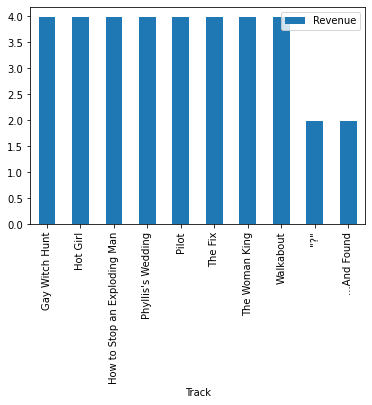

In [39]:
df[['Track', 'Revenue']].plot(kind='bar', x='Track')

## 2- country generates the most revenue

### query:
`
SELECT BillingCountry, ROUND(SUM(Total), 2) As Total_Revenue 
FROM Invoice 
GROUP BY BillingCountry
ORDER BY Total_Revenue DESC
LIMIT 1;
`

In [22]:
Invoice_table_query = "SELECT * FROM Invoice"
cur.execute(Invoice_table_query)

In [23]:
Invoice_table = pd.DataFrame(cur.fetchall(), columns =['InvoiceId', 'CustomerId', 'InvoiceDate', 'BillingAddress', 'BillingCity', 'BillingState', 'BillingCountry', 'BillingPostalCode', 'Total'])
Invoice_table = Invoice_table.set_index("InvoiceId")
Invoice_table.head()

,CustomerId,InvoiceDate,BillingAddress,BillingCity,BillingState,BillingCountry,BillingPostalCode,Total
InvoiceId,,,,,,,,
1,2,2021-01-01 00:00:00,Theodor-Heuss-Straße 34,Stuttgart,None,Germany,70174,1.98
2,4,2021-01-02 00:00:00,Ullevålsveien 14,Oslo,None,Norway,0171,3.96
3,8,2021-01-03 00:00:00,Grétrystraat 63,Brussels,None,Belgium,1000,5.94
4,14,2021-01-06 00:00:00,8210 111 ST NW,Edmonton,AB,Canada,T6G 2C7,8.91
5,23,2021-01-11 00:00:00,69 Salem Street,Boston,MA,USA,2113,13.86


In [24]:
Invoice_query_table = Invoice_table[['BillingCountry', 'Total']].groupby("BillingCountry").agg(Total=("Total", "sum"))
Invoice_query_table.sort_values("Total", ascending=False, inplace=True)
Invoice_query_table.head(5)

,Total
BillingCountry,
USA,523.06
Canada,303.96
France,195.10
Brazil,190.10
Germany,156.48


In [25]:
query = """SELECT BillingCountry, ROUND(SUM(Total), 2) As Total_Revenue 
FROM Invoice 
GROUP BY BillingCountry
ORDER BY Total_Revenue DESC
LIMIT 1;
"""
cur.execute(query)

In [26]:
most_revenue_country = cur.fetchone()

print(f"Top #1 Country: {most_revenue_country[0]} with Revenue = ${most_revenue_country[1]}")

Top #1 Country: USA with Revenue = $523.06


## 3- Who is the top-performing sales employee

### query:
`
SELECT (e.firstName || " " || e.LastName) AS EmployeeName, ROUND(SUM(i.Total), 2) AS TotalSales 
FROM Invoice AS i
JOIN Customer AS c ON i.CustomerId = c.CustomerId 
JOIN Employee AS e ON c.SupportRepId = e.EmployeeId 
GROUP BY e.EmployeeId
ORDER BY TotalSales DESC
LIMIT 1;
`

In [69]:
query = """SELECT (e.firstName || " " || e.LastName) AS EmployeeName, ROUND(SUM(i.Total), 2) AS TotalSales 
FROM Invoice AS i
JOIN Customer AS c ON i.CustomerId = c.CustomerId 
JOIN Employee AS e ON c.SupportRepId = e.EmployeeId 
GROUP BY e.EmployeeId
ORDER BY TotalSales DESC
LIMIT 1;"""

cur.execute(query)

In [70]:
top_sales_employee = cur.fetchone()

In [71]:
print(f"Top sales Employee: {top_sales_employee[0]} with sales= ${top_sales_employee[1]}")

Top sales Employee: Jane Peacock with sales= $833.04


In [72]:
query="""Select Title, FirstName, LastName 
FROM Employee 
where FirstName ="Jane" """

In [73]:
cur.execute(query)
cur.fetchall()

[('Sales Support Agent', 'Jane', 'Peacock')]